In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import os

In [16]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root='dataset/train', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

class_names = train_dataset.classes
print(f"Найденные команды: {class_names}")

class HandGestureCNN(nn.Module):
    def __init__(self, num_classes=len(class_names)):
        super(HandGestureCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 32 * 32, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HandGestureCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 15
print("Старт обучения...")

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Эпоха [{epoch+1}/{epochs}] — Ошибка (Loss): {running_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), 'hand_model.pth')
print("Модель обучена и сохранена!")

Найденные команды: ['heart', 'open_palm', 'pointing_finger', 'thumb_up']
Старт обучения...
Эпоха [1/15] — Ошибка (Loss): 1.7328
Эпоха [2/15] — Ошибка (Loss): 1.0370
Эпоха [3/15] — Ошибка (Loss): 0.8382
Эпоха [4/15] — Ошибка (Loss): 1.1179
Эпоха [5/15] — Ошибка (Loss): 0.6250
Эпоха [6/15] — Ошибка (Loss): 0.3845
Эпоха [7/15] — Ошибка (Loss): 0.2550
Эпоха [8/15] — Ошибка (Loss): 0.1395
Эпоха [9/15] — Ошибка (Loss): 0.0831
Эпоха [10/15] — Ошибка (Loss): 0.0456
Эпоха [11/15] — Ошибка (Loss): 0.0290
Эпоха [12/15] — Ошибка (Loss): 0.0175
Эпоха [13/15] — Ошибка (Loss): 0.0112
Эпоха [14/15] — Ошибка (Loss): 0.0055
Эпоха [15/15] — Ошибка (Loss): 0.0040
Модель обучена и сохранена!


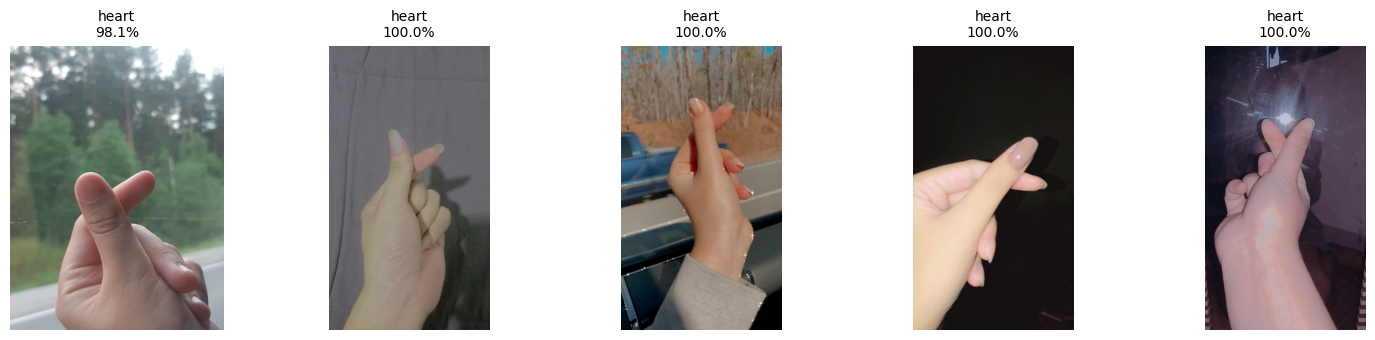

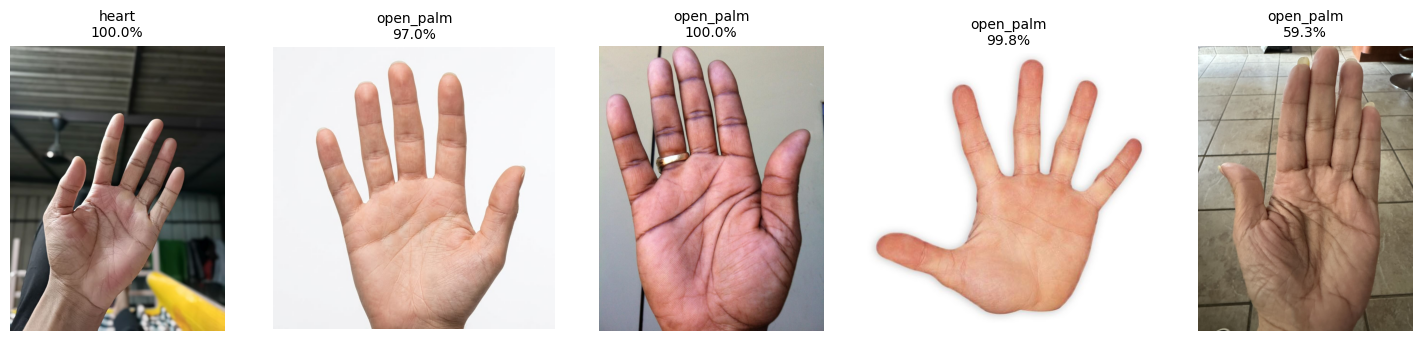

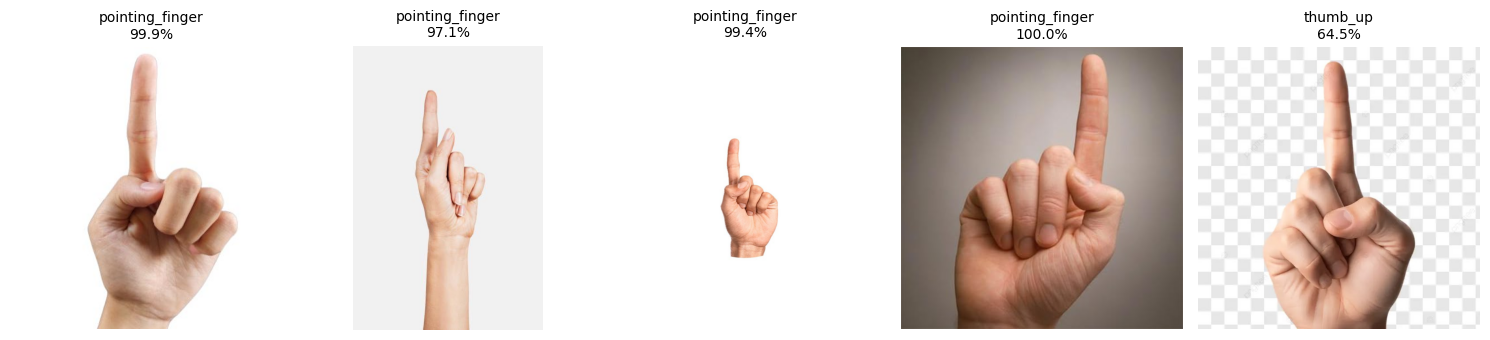

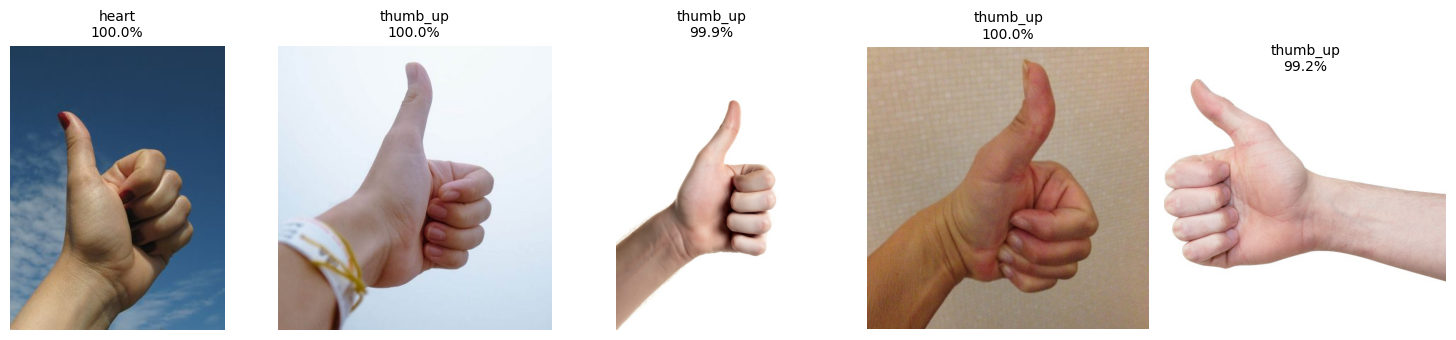

In [17]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_model = HandGestureCNN(num_classes=len(class_names)).to(device)
test_model.load_state_dict(torch.load('hand_model.pth', map_location=device))
test_model.eval()

test_dir = 'dataset/test'
image_paths = []

for root, dirs, files in os.walk(test_dir):
    for file in files:
        if file.endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(root, file))

cols = 5
total_images = len(image_paths)

for i in range(0, total_images, cols):
    batch_paths = image_paths[i:i + cols]
    
    fig, axes = plt.subplots(1, len(batch_paths), figsize=(15, 3.5))
    
    if len(batch_paths) == 1:
        axes = [axes]

    for ax, path in zip(axes, batch_paths):
        image = Image.open(path).convert('RGB')
        input_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = test_model(input_tensor)
            probs = F.softmax(output, dim=1)

        confidence, class_idx = torch.max(probs, 1)
        command = class_names[class_idx.item()]
        percent = confidence.item() * 100

        ax.imshow(image)
        ax.set_title(f"{command}\n{percent:.1f}%", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()